In [3]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2,3"  
# os.environ["CUDA_VISIBLE_DEVICES"] = "2,3"  
from torch import nn


import numpy as np                                                                  
import torch                                          

                              
from transformers import AutoModelForCausalLM, AutoTokenizer  
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt  
import torch.nn.functional as F
import gc
import re
import copy

import JCBScope_utils

# Move to GPU with optimal dtype
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = "cpu"


/home/jl3499/conda/LLM1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/jl3499/conda/LLM1/lib/python3.12/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [4]:
# Deep clean CUDA GPU memory
torch.cuda.empty_cache()
torch.cuda.ipc_collect()
gc.collect()

    

174

In [ ]:
# Load the tokenizer and model

model_name = "meta-llama/Llama-3.2-1B"
# model_name = "meta-llama/Llama-3.2-3B"

if device == "cpu":
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(model_name)
    model = model.to(device)
else:
    tokenizer = AutoTokenizer.from_pretrained(model_name, device_map="auto")
    model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto")

### Set input strings

In [19]:
### Pad inputs with BOS tokens
front_pad = 2

### Lorenz system
# string = '50,52,54,57,62,71,80,80,68,57,52,50,49,48,46,42,35,23,14,24,40,49,54,57,60,66,74,79,74,64,58,55,55,57,61,68,77,80,71,60,54,52,51,52,53,55,61,70,83,83,66,53,47,44,41,36,28,22,23,32,40,44,44,43,40,33,24,19,26,37,44,47,47,47,45,40,32,21,16,28,42,49,52,55,58,63,71,80,79,67,58,53,51,51,51,52,55,59,69,82,84,69,54,47,43,40,35,28,22,24,32,39,43,43,41,37,30,22,22,31,39,44,45,44,41,36,27,19,22,34,43,47,49,49,48,47,45,40,31,18,15,31,46,53,57,60,65,72,77,75,67,60,57,57,59,64,71,78,77,68,60,56,55,56,60,66,75,81,75,63,56,53,52,52,54,57,62,73,84,80,64,53,48,45,42,37,30,21,21,31,40,45,46,46,44,40,32,22,17,27'
string = '80,68,57,52,50,49,48,46,42,35,23,14,24,40,49,54,57,60,66,74,79,74,64,58,55,55,57,61,68,77,80,71,60,54,52,51,52,53,55,61,70,83,83,66,53,47,44,41,36,28,22,23,32,40,44,44,43,40,33,24,19,26,37,44,47,47,47,45,40,32,21,16,28,42,49,52,55,58,63,71,80,79,67,58,53,51,51,51,52,55,59,69,82,84,69,54,47,43,40,35,28,22,24,32,39,43,43,41,37,30,22,22,31,39,44,45,44,41,36,27,19,22,34,43,47,49,49,48,47,45,40,31,18,15,31,46,53,57,60,65,72,77,75,67,60,57,57,59,64,71,78,77,68,60,56,55,56,60,66,75,81,75,63,56,53,52,52,54,57,62,73,84'

### Lobe switching

# string = '51,53,55,58,65,75,83,76,62,54,51,49,49,47,45,40,29,16,17,35,48,54,57,62,68,76,79,72,63,57,56,58,61,69,78,80,71,60,55,54,54,57,62,72,82,80,66,55,51,49,48,46,42,34,22,14,26,42,50,54,57,61,68,77,81,72,61,55,53,53,55,59,67,79,84,71,58,51,48,46,43,38,28,18,20,34,45,49,51,53,55,59,67,80,84,71,57,49,46,44,39,32,22,19,28,40,46,48,48,47,44,39,29,16,18,35,47,52,55,59,64,73,80,77,65,57,54,53,55,58,64,75,84,77,62,53,49,47,45,42,34,23,16,25,40,48,51,53,55,60,68,79,83,71,58,51,49,47,44,40,32,20,17,30,43,49,52,54,57,63,73,83,79,65,55,50,49,47,45'

### Lorenz with drift 0.2
# string = '29,30,31,33,36,40,45,45,39,34,32,31,31,30,30,28,25,19,14,19,28,33,35,37,39,42,47,49,47,42,39,38,38,39,42,46,50,52,48,42,39,38,38,39,40,41,44,49,56,56,48,41,38,37,36,33,30,27,28,32,37,39,39,39,37,34,30,28,31,37,41,42,43,43,42,40,36,30,28,35,42,46,48,49,51,54,58,63,62,56,52,50,49,49,50,50,52,55,60,67,68,59,52,49,48,46,44,40,38,39,44,47,49,50,49,47,43,40,40,45,49,52,53,52,51,48,44,40,43,49,53,56,57,57,57,56,55,53,48,42,42,50,58,61,63,65,68,72,75,73,69,66,65,65,67,69,73,77,76,72,68,66,66,67,69,73,78,80,77,72,68,67,67,67,68,70,73,79,84'

### Lorenz with drift 0.4
# string = '21,22,23,25,27,30,33,33,30,26,25,24,24,24,24,23,21,17,14,18,24,27,29,30,32,34,37,39,38,35,33,32,32,33,35,38,41,42,39,36,34,34,34,34,35,36,38,42,46,46,41,37,35,35,34,32,30,28,29,32,35,37,37,37,36,34,32,30,33,37,40,41,41,41,41,40,37,34,33,37,42,45,46,47,48,50,54,57,56,53,50,49,48,49,49,50,51,53,56,61,62,57,52,50,49,48,47,45,43,44,47,50,51,52,51,50,48,46,46,49,53,54,55,55,54,53,50,48,49,53,57,58,59,59,60,59,59,58,54,50,50,56,61,64,65,67,69,72,73,73,70,68,68,68,69,71,74,76,76,73,71,70,70,71,72,75,78,80,78,75,72,72,72,72,73,74,77,81,84'

### Lorenz with drift 0.6
# string = '18,19,19,20,22,25,27,28,25,22,21,21,21,21,21,21,19,16,14,17,22,24,26,27,28,30,32,34,33,31,29,29,29,30,32,34,36,37,35,33,32,31,32,32,33,34,35,38,42,42,38,35,34,33,33,32,30,29,30,32,35,36,36,36,36,35,33,32,34,37,39,40,41,41,40,40,38,35,35,38,42,44,45,46,47,49,51,54,54,51,49,48,48,48,49,49,50,52,55,58,59,55,52,50,50,49,48,47,46,47,49,51,52,53,53,52,50,49,49,52,54,56,56,56,56,55,53,51,53,56,58,60,60,61,61,61,61,60,58,55,55,59,63,65,66,68,69,71,73,73,71,69,69,69,70,72,74,76,76,74,72,72,72,73,74,76,78,80,79,76,75,74,74,75,75,77,79,82,84'

### Brownian motion
# string = '28,28,31,26,29,27,19,16,19,21,15,18,18,20,21,16,18,14,22,26,26,21,21,22,16,27,29,37,32,40,33,30,33,33,21,16,20,30,35,34,37,32,34,28,28,27,31,29,35,34,39,42,33,34,34,30,31,24,26,29,30,43,44,45,41,42,38,44,41,42,51,57,58,65,65,69,69,65,67,71,70,64,62,50,47,41,51,49,41,45,44,45,46,47,45,50,52,50,49,44,46,49,52,55,55,63,62,62,60,60,59,69,71,63,61,54,58,65,63,66,65,67,75,74,68,71,74,77,82,79,69,74,72,66,60,66,67,68,73,69,64,60,54,53,48,48,46,46,49,56,63,64,65,63,68,75,72,76,74,73,74,72,77,69,66,65,60,62,55,55,48,47,49,60,66,74,74,84'
# string = "34,32,35,36,32,21,25,30,23,31,29,41,44,42,48,48,49,49,48,51,55,57,65,59,57,60,55,62,65,64,67,64,57,61,66,66,66,56,53,51,52,58,56,52,56,56,50,55,51,49,44,46,50,49,51,48,59,66,63,65,70,72,68,68,71,73,69,71,66,57,57,62,64,70,78,80,77,77,70,70,70,71,75,66,69,67,70,71,66,70,67,69,67,65,65,74,77,77,84,84,83,79,80,80,77,68,68,68,66,62,57,55,61,62,54,57,55,66,65,64,65,66,67,67,66,63,62,56,54,51,49,47,46,48,47,47,49,47,47,48,40,43,41,25,27,21,26,21,20,23,20,15,14,21,26,32,34,36,41,43,40,43,41,37,38,38,42,43,41,41,38,37,42,44,43,41,38,38,31,34"
# string = "57,65,63,63,65,61,61,61,53,58,61,58,57,59,58,57,51,53,54,55,48,55,56,54,63,63,57,55,45,49,47,44,49,41,44,35,32,26,33,41,39,43,42,45,41,34,26,27,37,39,36,45,46,46,48,47,46,39,41,41,46,45,36,36,43,42,38,32,27,26,21,28,26,27,33,40,39,41,44,43,35,38,42,44,40,39,36,35,41,47,50,53,56,56,56,53,52,62,66,65,63,59,61,62,56,58,55,62,63,70,68,67,68,73,76,70,71,71,69,66,74,72,68,71,72,72,75,77,79,83,84,82,80,78,79,74,66,66,60,51,53,50,52,49,44,39,37,35,32,30,23,23,15,14,18,23,30,23,27,32,37,32,34,43,36,38,43,40,42,38,34,30,31,31,35,31,30,35,37,31"
# string = "42,42,47,39,33,24,33,41,50,53,57,52,60,55,53,51,48,51,50,50,49,55,52,52,53,47,45,47,52,52,50,56,55,55,55,55,53,55,50,48,46,43,43,43,44,43,45,52,57,44,48,41,33,34,28,35,37,34,27,29,34,34,42,44,47,46,48,47,39,49,49,49,55,55,56,58,53,59,61,58,62,64,60,60,60,62,63,66,61,61,57,59,54,45,43,54,58,59,69,68,67,71,72,72,70,70,74,69,66,71,82,74,76,83,82,79,84,82,79,77,71,61,66,73,74,73,75,74,67,62,64,62,56,50,54,48,52,54,50,49,49,51,52,58,62,60,59,55,53,53,44,44,44,43,37,35,32,32,21,20,22,18,14,18,28,31,34,34,37,40,36,37,41,38,40,45,49,49,57,62"
# string = "36,36,35,31,31,29,28,22,20,19,17,19,26,27,29,36,38,44,40,40,45,47,47,51,52,54,53,53,55,53,45,45,54,44,40,40,41,45,49,54,59,56,56,54,56,55,51,58,58,55,58,54,52,49,42,32,32,29,27,30,26,33,26,16,15,17,23,21,19,19,28,21,22,22,19,17,18,14,15,17,20,18,17,17,20,21,25,27,21,25,23,25,25,28,28,29,23,28,28,26,31,33,34,36,36,32,28,31,35,37,38,42,46,48,51,55,53,56,52,43,46,45,52,47,51,50,51,47,56,55,62,62,57,54,59,57,57,63,67,63,62,68,66,69,70,65,66,64,65,62,64,64,67,63,63,67,71,75,78,75,77,80,81,83,82,84,84,80,75,79,75,71,65,72,80,77,70,67,64,63"


# ### Logistic map
# string = "81,28,67,64,71,56,80,30,72,54,82,24,60,76,43,84,17,40,82,22,54,82,25,61,74,48,84,15,35,78,37,79,32,74,48,84,15,35,78,37,80,30,71,56,80,29,70,59,78,38,81,28,67,65,68,61,74,48,84,15,34,77,40,82,23,57,80,31,73,51,84,17,42,83,19,47,84,15,34,76,42,83,18,45,84,15,35,77,39,82,25,62,74,49,84,15,36,79,33,75,44,84,16,37,80,31,73,52,83,19,47,84,14,34,76,42,83,18,45,84,15,36,79,35,77,38,81,27,65,69,61,75,45,84,15,35,77,39,81,25,62,73,51,84,18,44,84,15,37,80,32,73,50,84,16,38,81,28,67,65,68,63,72,54,82,24,59,77,38,81,27,66,66,66,66,67,65,68,62,73"
# string = "34,80,28,74,45,84,15,50,83,21,63,68,59,74,46,84,15,51,82,22,66,64,67,62,70,56,78,34,81,27,73,47,84,16,53,81,28,74,46,84,16,52,82,24,69,58,76,40,84,17,54,80,29,76,40,84,16,54,80,28,74,45,84,15,50,83,20,62,70,55,79,32,79,33,80,28,75,44,84,14,49,83,19,59,74,46,84,15,51,82,22,66,64,67,62,70,55,79,32,79,32,79,33,79,31,78,36,82,22,66,64,67,62,70,56,78,34,80,28,74,45,84,15,50,83,20,61,72,51,82,22,66,64,67,61"
# string = "74,45,84,15,50,83,21,63,69,57,77,37,83,20,61,72,50,83,21,63,69,58,76,41,84,16,52,82,24,69,58,76,42,84,15,50,83,21,62,70,56,78,36,82,23,66,63,69,59,75,43,84,15,49,83,19,60,73,48,84,17,55,79,32,79,34,80,28,75,44,84,15,49,83,19,60,74,47,84,16,53,81,26,71,53,81,26,72,52,82,24,68,59,75,43,84,15,49,83,19,60,74,47,84,16"



### Scope Type

In [20]:
mode = 'Temperature'
# mode = 'Semantic'
if mode not in ["Temperature", "Semantic"]:
    raise ValueError(f"Invalid mode '{mode}'. Mode must be either 'Temperature' or 'Semantic'.")

In [21]:
# Deep clean CUDA GPU memory
torch.cuda.empty_cache()
torch.cuda.ipc_collect()
gc.collect()


5621

In [22]:
# Hyperparameters

back_pad = 0

# Get special tokens if available
bos_token_id = tokenizer.bos_token_id if tokenizer.bos_token_id is not None else tokenizer.cls_token_id
eos_token_id = tokenizer.eos_token_id if tokenizer.eos_token_id is not None else tokenizer.sep_token_id

# Prepare input: pad both ends with special tokens
input_ids_list = []

# Pad the front
if bos_token_id is not None:
    input_ids_list += [bos_token_id] * front_pad

# Main tokens
input_ids_list += tokenizer(string, add_special_tokens=False)["input_ids"]

# Pad the back
if eos_token_id is not None:
    input_ids_list += [eos_token_id] * back_pad

input_ids = torch.tensor([input_ids_list], dtype=torch.long).to(device)
attention_mask = torch.ones_like(input_ids)

print("input_ids:", input_ids)
print("vocab size:", model.config.vocab_size)
assert input_ids.max() < model.config.vocab_size

seq_len = input_ids.size(1)

# Optional: print tokens
for i, tok in enumerate(input_ids[0]):
    print(i, tok.item(), repr(tokenizer.decode(tok.item(), skip_special_tokens=False)))

decoded_tokens = [tokenizer.decode(token_id.item(), skip_special_tokens=True) for token_id in input_ids[0]]

print(decoded_tokens)


input_ids: tensor([[128000, 128000,   1490,     11,   2614,     11,   3226,     11,   4103,
             11,   1135,     11,   2491,     11,   2166,     11,   2790,     11,
           2983,     11,   1758,     11,   1419,     11,    975,     11,   1187,
             11,   1272,     11,   2491,     11,   4370,     11,   3226,     11,
           1399,     11,   2287,     11,   5728,     11,   4643,     11,   5728,
             11,   1227,     11,   2970,     11,   2131,     11,   2131,     11,
           3226,     11,   5547,     11,   2614,     11,   2813,     11,   1490,
             11,   6028,     11,   1399,     11,   4370,     11,   4103,     11,
           3971,     11,   4103,     11,   4331,     11,   2131,     11,   5547,
             11,   2031,     11,   6069,     11,   6069,     11,   2287,     11,
           4331,     11,   2618,     11,   2096,     11,   3174,     11,   1927,
             11,   1591,     11,   1313,     11,   1419,     11,    843,     11,
           1272, 

In [23]:
### Set which tokens to perform gradients on
### Skip comma delimiters
grad_idx = [idx for idx in range(front_pad,len(decoded_tokens),2)]

print(grad_idx)

[2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42, 44, 46, 48, 50, 52, 54, 56, 58, 60, 62, 64, 66, 68, 70, 72, 74, 76, 78, 80, 82, 84, 86, 88, 90, 92, 94, 96, 98, 100, 102, 104, 106, 108, 110, 112, 114, 116, 118, 120, 122, 124, 126, 128, 130, 132, 134, 136, 138, 140, 142, 144, 146, 148, 150, 152, 154, 156, 158, 160, 162, 164, 166, 168, 170, 172, 174, 176, 178, 180, 182, 184, 186, 188, 190, 192, 194, 196, 198, 200, 202, 204, 206, 208, 210, 212, 214, 216, 218, 220, 222, 224, 226, 228, 230, 232, 234, 236, 238, 240, 242, 244, 246, 248, 250, 252, 254, 256, 258, 260, 262, 264, 266, 268, 270, 272, 274, 276, 278, 280, 282, 284, 286, 288, 290, 292, 294, 296, 298, 300, 302, 304, 306, 308, 310, 312, 314, 316, 318, 320, 322, 324, 326, 328, 330, 332, 334, 336, 338, 340, 342, 344]


### Construct backprop variables

In [24]:
embedding_layer = model.get_input_embeddings()
d_model = embedding_layer.embedding_dim

residual = nn.Parameter(torch.zeros(len(grad_idx), d_model, device=model.device))
# presence = nn.Parameter(torch.ones(len(grad_idx), 1, device=model.device))
presence = torch.ones(len(decoded_tokens), 1, device=model.device)

optimizer = torch.optim.SGD([residual], lr=1e-3)

### Build forward function

In [25]:
forward_pass = JCBScope_utils.customize_forward_pass(model, residual, presence, input_ids, grad_idx, attention_mask)

In [ ]:
if mode == 'Temperature':
    hidden_norm_as_loss = True
elif mode == 'Semantic':
    hidden_norm_as_loss = False

print(f"Computing {mode} Scope...")    
unnormalized_logits = True # use raw logits instead of likelihood
loss_position = grad_idx[-1]-1


optimizer.zero_grad()
loss, logits = forward_pass(loss_position=loss_position,
                            hidden_norm_as_loss=hidden_norm_as_loss, 
                            unnormalized_logits = unnormalized_logits,
                            tie_input_output_embed = False)

grads = torch.autograd.grad(loss, residual, retain_graph=True)[0]

# optimizer.step()
print(f"loss = {loss.item():.4f}")
    


Computing Temperature Scope...
loss = 85.0035


In [27]:
true_target = decoded_tokens[loss_position+1]
from matplotlib.colors import Normalize as Norm, LogNorm as Log_Norm

### Visualize prediction

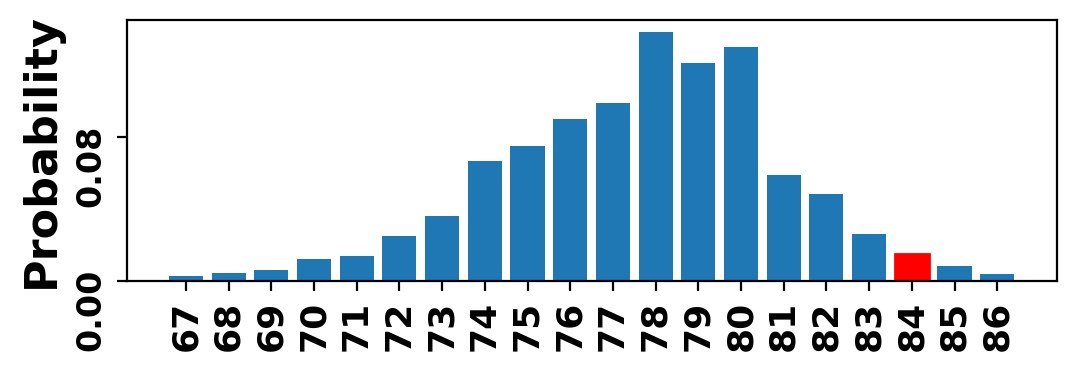

In [28]:
context_position = loss_position
import torch
k = 20


# Assuming 'logits' is of shape [batch, seq_len, vocab_size]
# and 'step' corresponds to the time-step dimension (seq_len)
logit_vector = logits[context_position].detach()             # shape: [vocab_size]

# Compute softmax probabilities
probs = torch.softmax(logit_vector, dim=-1)

# Get top k probabilities and their indices
top_probs, top_indices = torch.topk(probs, k)
top_tokens = [tokenizer.decode([idx]) for idx in top_indices]
# Reorder top_probs and top_tokens by int(top_tokens)
sorted_with_probs = sorted(zip(top_tokens, top_probs), key=lambda x: int(x[0]))
top_tokens, top_probs = zip(*sorted_with_probs)
top_probs = torch.stack(top_probs) if isinstance(top_probs[0], torch.Tensor) else torch.tensor(top_probs)



import matplotlib.pyplot as plt

plt.figure(figsize=(6,1.7), dpi=200)
bars = plt.bar(range(k), top_probs.cpu().numpy(), tick_label=top_tokens)
# Color the bar at true_target in red
for i, token in enumerate(top_tokens):
    if token == true_target:
        bars[i].set_color('red')
        # Add legend for the red bar as "target"
        # bars[i].set_label("target")
        # leg = plt.legend(loc='upper right', fontsize=12)
        break
else:
    print("true token not found")
plt.xticks(rotation=90, fontweight='bold', fontsize=13)
plt.ylabel('Probability', fontweight='bold', fontsize=16,rotation=90)
plt.yticks(rotation=90, fontweight='bold', fontsize=12)
# plt.xlabel('Token')
plt.gca().yaxis.set_major_locator(plt.MaxNLocator(nbins=2))  # increase number of ticks

plt.show()

### Visualization for time-series data

/data/tmp/ipykernel_3837696/1255145933.py:101: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax2.scatter(


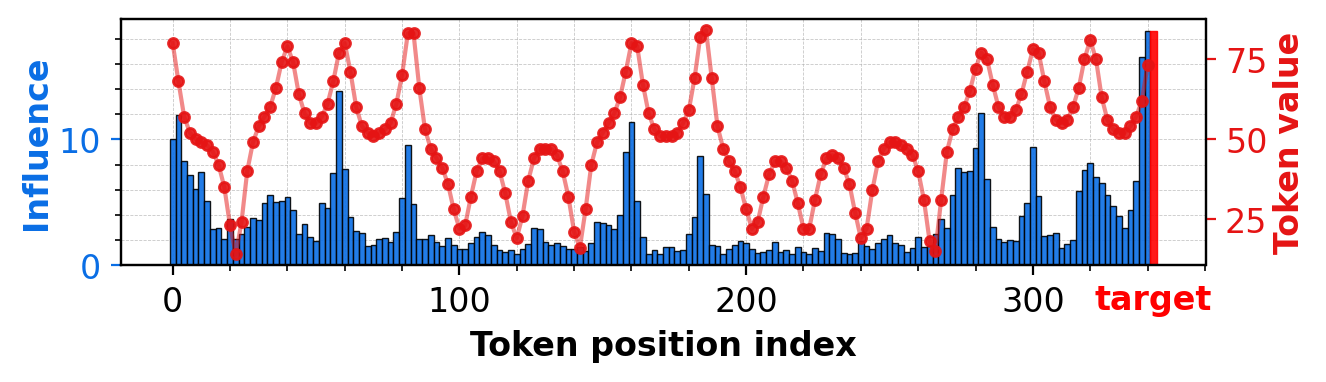

In [29]:
# Hyperparameters
label_font_size = 12
step_idx = 0
hardset_target_grad = True
log_color = 1
show_bars = True

surpress_last_value = 1

# Axes color hyperparameters
ax1_color = 'blue'
ax2_color = 'red'

ax1_color = np.array([10, 110, 230])/256
ax2_color = np.array([230, 20, 20])/256

cmap = plt.get_cmap('coolwarm')
# cmap = plt.get_cmap('inferno')
# cmap = plt.get_cmap('viridis')
# cmap = plt.get_cmap('Blues')


x_labels = [x-front_pad for x in grad_idx]


if len(grads.shape) == 2:
    grad_magnitude = grads.norm(dim=-1).squeeze()  # shape [seq_len]
else:
    grad_magnitude = grads.clone()
    
int_list = [int(x) for x in string.split(',')]
if surpress_last_value:
    int_list = int_list[:-1]

if hardset_target_grad:
    grad_magnitude[grad_idx.index(loss_position+1)] = max(grad_magnitude)

plt.figure(figsize=(7, 1.6), dpi=200)

if show_bars:
    bars = plt.bar(
        range(grad_magnitude.shape[0]),
        grad_magnitude, 
        tick_label=x_labels,
        color=ax1_color,
        linewidth=0.5,        # Smaller bar edge
        edgecolor='black',     # Remove edge color to help overlap
        width=1.0,            # Make bars full width; may cause overlap at dense ticks
        alpha=0.9             # Let bars visually overlap via alpha (transparency)
    )
    target_bar_index = grad_idx.index(loss_position+1)
    bars[target_bar_index].set_color('red')
    bars[target_bar_index].set_width(1.1)  # make this specific bin larger

ax = plt.gca()
ax2 = ax.twinx()

# Normalize grad_magnitude for color mapping
log_norm = Log_Norm(vmin=grad_magnitude[:grad_idx.index(loss_position+1)].min(), vmax=grad_magnitude.max())
norm = Norm(vmin=grad_magnitude[:grad_idx.index(loss_position+1)].min(), vmax=grad_magnitude.max())

under_sample_rate = 50
xticks = ax.get_xticks()
xticklabels = ax.get_xticklabels()
# Only keep every Nth tick and label
new_xticks = [tick for i, tick in enumerate(xticks) if i % under_sample_rate == 0]
new_xticklabels = [label.get_text() for i, label in enumerate(xticklabels) if i % under_sample_rate == 0]
# ax.set_xticks(new_xticks+[grad_idx.index(loss_position+1)])
ax.set_xticks(new_xticks+[grad_idx.index(loss_position+1)])

# Build labels, with last ("target") in red via Text objects
xtick_labels = []

# Matplotlib's set_xticklabels normally expects strings or Text instances, but to ensure color:
# Set all to black but override the last in-place after drawing
ax.set_xticklabels(new_xticklabels + ["target"], fontsize=label_font_size)
# Suppress the tick but keep only the label for the last xtick
# Get all xticks and xticklabels
xticks = ax.get_xticks()
labels = ax.get_xticklabels()

# Hide the tick for the last xtick but keep its label, and color it red
if len(xticks) > 0 and len(labels) > 0:
    last_tick_index = -1
    # Set the label color to red
    labels[last_tick_index].set_color('red')
    # Hide the tick by overlaying an 'empty' tick at its position
    tick_locs = xticks.tolist()
    if len(tick_locs) > 1:
        tick_locs_no_last = tick_locs[:-1]
        label_texts_no_last = [l.get_text() for l in labels[:-1]]
        # Set ticks and labels, then add the last label only manually as text
        ax.set_xticks(tick_locs_no_last)
        ax.set_xticklabels(label_texts_no_last, fontsize=label_font_size)
        # add the last label manually
        ax.text(tick_locs[-1], ax.get_yticks()[0] - 0.07 * (ax.get_ylim()[1] - ax.get_ylim()[0]), labels[-1].get_text(),
                color='red', fontsize=label_font_size, va='top', ha='center', fontweight='bold')

    

ax2.scatter(
    range(len(int_list)), int_list,
    c=ax2_color, marker='o', s=13, alpha=0.9
)
ax2.plot(
    range(len(int_list)), int_list,
    c=ax2_color, linewidth=1.5, alpha=0.5
)
ax2.tick_params(axis='y', colors=ax2_color, labelsize=label_font_size)
ax.tick_params(axis='y', colors=ax1_color, labelsize=label_font_size)

ax.set_xlabel('Token position index', fontsize=label_font_size, fontweight='bold')
ax.set_ylabel('Influence', labelpad=2, color=ax1_color, fontsize=label_font_size, fontweight='bold')
ax2.set_ylabel('Token value', labelpad=2, color=ax2_color, fontsize=label_font_size, fontweight='bold')

ax.set_axisbelow(True)
ax.xaxis.grid(True, which='both', linestyle='--', linewidth=0.3, alpha=0.7)
ax.yaxis.grid(True, which='both', linestyle='--', linewidth=0.3, alpha=0.7)
ax.minorticks_on()
# plt.tight_layout()


# plt.colorbar(sm, ax=[ax2], pad=0.05, label='Attribution magnitude')

plt.show()